In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import download_prices, get_log_prices
from src.signals import (
    rolling_hedge_ratio,
    compute_rolling_spread,
    compute_rolling_zscore,
    generate_positions,
)
from src.backtest import run_backtest
from src.metrics import summarize_results

In [2]:
tickers = ["KO", "PEP"]
start = "2015-01-01"
end = "2022-01-01"

prices = download_prices(tickers, start=start, end=end)
lp = get_log_prices(prices)

prices.head()


[*********************100%***********************]  2 of 2 completed


Ticker,KO,PEP
Date,,
2015-01-02,29.390263,66.582939
2015-01-05,29.390263,66.082375
2015-01-06,29.613438,65.581787
2015-01-07,29.983095,67.499451
2015-01-08,30.345755,68.726242


In [3]:
window = 60
entry = 2.0
exit = 0.5
tc_rate = 0.0005
slippage_rate = 0.0005

In [4]:
hedge_ratios = rolling_hedge_ratio(lp, window=window)

spread = compute_rolling_spread(lp, hedge_ratios)

zscore = compute_rolling_zscore(spread, window=window)

positions = generate_positions(zscore, entry=entry, exit=exit)

In [5]:
results = run_backtest(
    prices=prices,
    positions=positions,
    hedge_ratios=hedge_ratios,
    tc_rate=tc_rate,
    slippage_rate=slippage_rate,
)

results.tail()

,positions,daily_pnl,cum_pnl,trading_costs,y_units,x_units
Date,,,,,,
2021-12-27,1,1.100685,23.280342,0.001065,1,-0.936507
2021-12-28,1,0.580020,23.860363,0.001335,1,-0.910617
2021-12-29,1,0.470752,24.331115,0.001283,1,-0.885774
2021-12-30,1,-0.129124,24.201991,0.001415,1,-0.858282
2021-12-31,1,0.575347,24.777338,0.001250,1,-0.834178


In [6]:
# 1) See what results actually is
print(type(results))
try:
    print(results.columns)
except Exception as e:
    print("results contents:", results)
    raise

# 2) See whether the summarize_results function in memory expects 'positions' or 'position'
import inspect
import src.metrics
print(inspect.getsource(src.metrics.summarize_results))

<class 'pandas.core.frame.DataFrame'>
Index(['positions', 'daily_pnl', 'cum_pnl', 'trading_costs', 'y_units',
       'x_units'],
      dtype='object')
def summarize_results(results):
    return {
        "total_pnl": results["cum_pnl"].iloc[-1],
        "sharpe": sharpe_ratio(results["daily_pnl"]),
        "max_drawdown": max_drawdown(results["cum_pnl"]),
        "num_trades": int((results["positions"].diff().fillna(results["positions"]) != 0).sum())
    }



In [7]:
summary = summarize_results(results)
summary

{'total_pnl': 24.777337964432498,
 'sharpe': 0.35296274690117146,
 'max_drawdown': -23.44350896811278,
 'num_trades': 77}

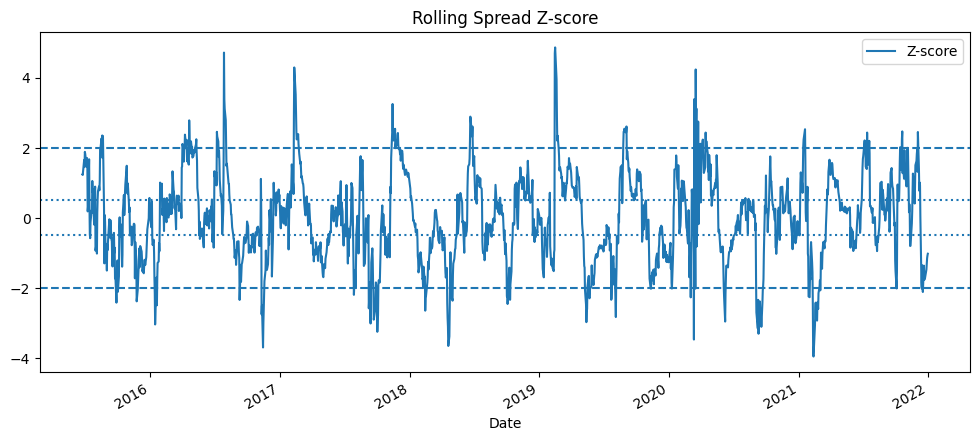

In [8]:
plt.figure(figsize=(12, 5))
zscore.plot(label="Z-score")
plt.axhline(entry, linestyle="--")
plt.axhline(-entry, linestyle="--")
plt.axhline(exit, linestyle=":")
plt.axhline(-exit, linestyle=":")
plt.title("Rolling Spread Z-score")
plt.legend()
plt.show()

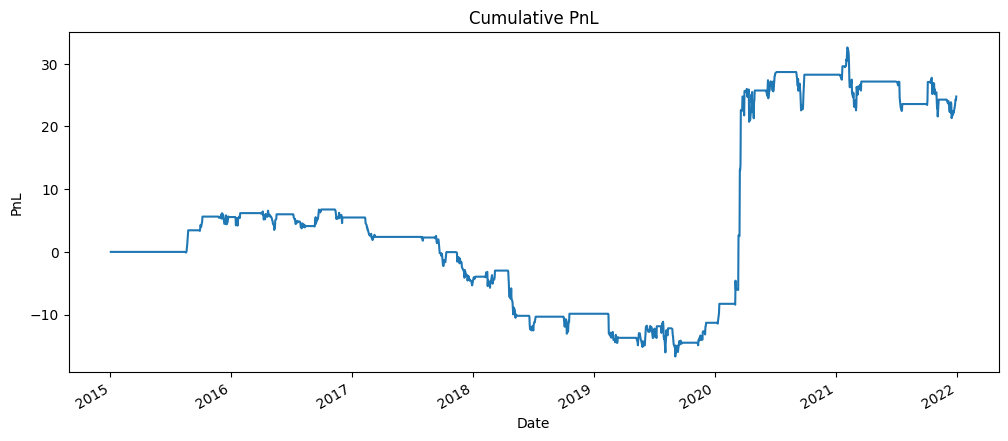

In [9]:
plt.figure(figsize=(12, 5))
results["cum_pnl"].plot()
plt.title("Cumulative PnL")
plt.ylabel("PnL")
plt.show()

In [10]:
experiments = []

for window in [30, 60, 90, 120]:
    for entry in [1.5, 2.0, 2.5]:
        hedge_ratios = rolling_hedge_ratio(lp, window=window)
        spread = compute_rolling_spread(lp, hedge_ratios)
        zscore = compute_rolling_zscore(spread, window=window)
        positions = generate_positions(zscore, entry=entry, exit=0.5)

        results = run_backtest(
            prices=prices,
            positions=positions,
            hedge_ratios=hedge_ratios,
            tc_rate=tc_rate,
            slippage_rate=slippage_rate,
        )

        summary = summarize_results(results)
        summary["window"] = window
        summary["entry"] = entry
        summary["exit"] = 0.5

        experiments.append(summary)

experiment_results = pd.DataFrame(experiments)
experiment_results.sort_values("sharpe", ascending=False)

,total_pnl,sharpe,max_drawdown,num_trades,window,entry,exit
5,20.959527,0.417831,-17.596609,42,60,2.5,0.5
4,24.777338,0.352963,-23.443509,77,60,2.0,0.5
3,21.029557,0.275865,-26.331788,105,60,1.5,0.5
7,18.650144,0.258741,-26.169575,60,90,2.0,0.5
2,11.629812,0.248311,-15.332493,64,30,2.5,0.5
8,14.562996,0.212922,-31.810734,42,90,2.5,0.5
11,11.991516,0.194626,-18.400132,32,120,2.5,0.5
6,10.387703,0.130398,-26.416273,83,90,1.5,0.5
10,5.288250,0.079162,-20.987985,46,120,2.0,0.5
0,-1.462328,-0.019872,-41.614462,202,30,1.5,0.5
